In [3]:
import pickle

# Load the graphs from the pickle file
with open("graphs_by_sample.pkl", "rb") as f:
    loaded_graphs = pickle.load(f)

In [5]:
import networkx as nx

# Get a list of all sample names (the keys)
sample_names = loaded_graphs.keys()

In [7]:
# Access an individual graph for a specific sample
first_sample_name = list(sample_names)[0]
a_single_graph = loaded_graphs[first_sample_name]

print(f"Type of object for '{first_sample_name}': {type(a_single_graph)}")
print(f"Number of nodes: {a_single_graph.number_of_nodes()}")
print(f"Number of edges: {a_single_graph.number_of_edges()}")

Type of object for 'TCGA_Tumor_A3A3': <class 'networkx.classes.graph.Graph'>
Number of nodes: 6496
Number of edges: 64794


In [18]:
import pandas as pd
import networkx as nx

def compute_metrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_deg = (2 * m) / n if n else 0
    trans = nx.transitivity(G)
    avg_clust = nx.average_clustering(G)
    try:
        lcc_size = max(len(c) for c in nx.connected_components(G))
    except nx.NetworkXError:
        lcc_size = 0
    return n, m, avg_deg, trans, avg_clust, lcc_size

rows = []
for sample_name, G in loaded_graphs.items():
    n, m, avg_deg, trans, avg_clust, lcc = compute_metrics(G)
    rows.append({
        "sample": sample_name,
        "nodes": n,
        "edges": m,
        "avg_degree": round(avg_deg, 2),
        "global_clustering": round(trans, 4),
        "avg_local_clustering": round(avg_clust, 4),
        "largest_connected_component": lcc
    })
    print(
        f"✅ {sample_name} | Nodes: {n} | Edges: {m} | "
        f"Avg Deg: {avg_deg:.2f} | Global Clust: {trans:.4f} | "
        f"Avg Clust: {avg_clust:.4f} | Largest Component: {lcc}"
    )

graph_df = pd.DataFrame(rows)
graph_df.head()

✅ TCGA_Tumor_A3A3 | Nodes: 6496 | Edges: 64794 | Avg Deg: 19.95 | Global Clust: 0.2261 | Avg Clust: 0.6576 | Largest Component: 6482
✅ TCGA_Tumor_A3RK | Nodes: 6518 | Edges: 65317 | Avg Deg: 20.04 | Global Clust: 0.2231 | Avg Clust: 0.6584 | Largest Component: 6504
✅ TCGA_Tumor_A3KG | Nodes: 6480 | Edges: 64995 | Avg Deg: 20.06 | Global Clust: 0.2257 | Avg Clust: 0.6605 | Largest Component: 6466
✅ TCGA_Tumor_AAU7 | Nodes: 6578 | Edges: 65735 | Avg Deg: 19.99 | Global Clust: 0.2210 | Avg Clust: 0.6588 | Largest Component: 6559
✅ TCGA_Tumor_A9VH | Nodes: 6535 | Edges: 65276 | Avg Deg: 19.98 | Global Clust: 0.2228 | Avg Clust: 0.6580 | Largest Component: 6516
✅ TCGA_Tumor_A5SL | Nodes: 6425 | Edges: 64458 | Avg Deg: 20.06 | Global Clust: 0.2288 | Avg Clust: 0.6572 | Largest Component: 6406
✅ TCGA_Healthy_A3CH | Nodes: 6500 | Edges: 64810 | Avg Deg: 19.94 | Global Clust: 0.2275 | Avg Clust: 0.6563 | Largest Component: 6481
✅ TCGA_Tumor_AAE0 | Nodes: 6438 | Edges: 64652 | Avg Deg: 20.08 | G

,sample,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component
0,TCGA_Tumor_A3A3,6496,64794,19.95,0.2261,0.6576,6482
1,TCGA_Tumor_A3RK,6518,65317,20.04,0.2231,0.6584,6504
2,TCGA_Tumor_A3KG,6480,64995,20.06,0.2257,0.6605,6466
3,TCGA_Tumor_AAU7,6578,65735,19.99,0.2210,0.6588,6559
4,TCGA_Tumor_A9VH,6535,65276,19.98,0.2228,0.6580,6516


In [20]:
graph_df['condition'] = graph_df['sample'].apply(lambda x: 'Healthy' if 'Healthy' in x else 'Tumor')

# Verify labels
print(graph_df[['sample', 'condition']].head(10))

              sample condition
0    TCGA_Tumor_A3A3     Tumor
1    TCGA_Tumor_A3RK     Tumor
2    TCGA_Tumor_A3KG     Tumor
3    TCGA_Tumor_AAU7     Tumor
4    TCGA_Tumor_A9VH     Tumor
5    TCGA_Tumor_A5SL     Tumor
6  TCGA_Healthy_A3CH   Healthy
7    TCGA_Tumor_AAE0     Tumor
8    TCGA_Tumor_A4NO     Tumor
9    TCGA_Tumor_A9GS     Tumor


## Difussion values per Graph

In [65]:
import pandas as pd
import networkx as nx

diffusion_rows = []

for sample_name, G in loaded_graphs.items():
    try:
        diff_eff = nx.global_efficiency(G)
        diffusion_rows.append({
            "sample": sample_name,
            "diffusion_efficiency": round(diff_eff, 4)
        })
        print(f"✅ {sample_name} → Diffusion efficiency: {diff_eff:.4f}")
    except Exception as e:
        print(f"❌ Error processing {sample_name}: {e}")

diffusion_df = pd.DataFrame(diffusion_rows)
diffusion_df.head()

✅ TCGA_Tumor_A3A3 → Diffusion efficiency: 0.3447
✅ TCGA_Tumor_A3RK → Diffusion efficiency: 0.3451
✅ TCGA_Tumor_A3KG → Diffusion efficiency: 0.3450
✅ TCGA_Tumor_AAU7 → Diffusion efficiency: 0.3440
✅ TCGA_Tumor_A9VH → Diffusion efficiency: 0.3438
✅ TCGA_Tumor_A5SL → Diffusion efficiency: 0.3444
✅ TCGA_Healthy_A3CH → Diffusion efficiency: 0.3434
✅ TCGA_Tumor_AAE0 → Diffusion efficiency: 0.3442
✅ TCGA_Tumor_A4NO → Diffusion efficiency: 0.3445
✅ TCGA_Tumor_A9GS → Diffusion efficiency: 0.3452
✅ TCGA_Tumor_AAEB → Diffusion efficiency: 0.3450
✅ TCGA_Tumor_5258 → Diffusion efficiency: 0.3451
✅ TCGA_Tumor_A25X → Diffusion efficiency: 0.3456
✅ TCGA_Healthy_A39X → Diffusion efficiency: 0.3444
✅ TCGA_Tumor_AACT → Diffusion efficiency: 0.3448
✅ TCGA_Tumor_A7MC → Diffusion efficiency: 0.3451
✅ TCGA_Healthy_A10Z → Diffusion efficiency: 0.3436
✅ TCGA_Healthy_A114 → Diffusion efficiency: 0.3443
✅ TCGA_Healthy_A1EB → Diffusion efficiency: 0.3447
✅ TCGA_Tumor_AACA → Diffusion efficiency: 0.3447
✅ TCGA_Tum

,sample,diffusion_efficiency
0,TCGA_Tumor_A3A3,0.3447
1,TCGA_Tumor_A3RK,0.3451
2,TCGA_Tumor_A3KG,0.3450
3,TCGA_Tumor_AAU7,0.3440
4,TCGA_Tumor_A9VH,0.3438


In [70]:
graph_df = graph_df.merge(diffusion_df, on='sample', how='left')
graph_df.head()

,sample,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component,condition,diffusion_efficiency
0,TCGA_Tumor_A3A3,6496,64794,19.95,0.2261,0.6576,6482,Tumor,0.3447
1,TCGA_Tumor_A3RK,6518,65317,20.04,0.2231,0.6584,6504,Tumor,0.3451
2,TCGA_Tumor_A3KG,6480,64995,20.06,0.2257,0.6605,6466,Tumor,0.3450
3,TCGA_Tumor_AAU7,6578,65735,19.99,0.2210,0.6588,6559,Tumor,0.3440
4,TCGA_Tumor_A9VH,6535,65276,19.98,0.2228,0.6580,6516,Tumor,0.3438


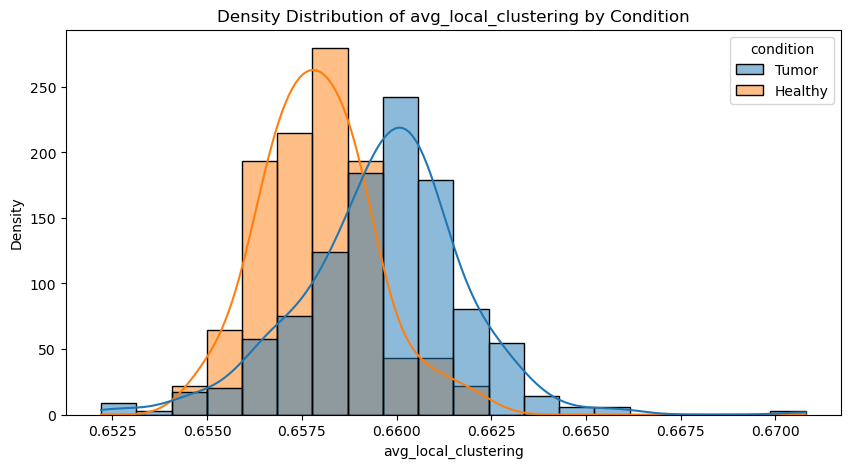

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

metric = 'avg_local_clustering'

plt.figure(figsize=(10,5))
sns.histplot(
    data=graph_df, x=metric, hue='condition', 
    bins=20, kde=True, stat='density', common_norm=False, alpha=0.5
)
plt.title(f"Density Distribution of {metric} by Condition")
plt.xlabel(metric)
plt.ylabel("Density")
plt.show()

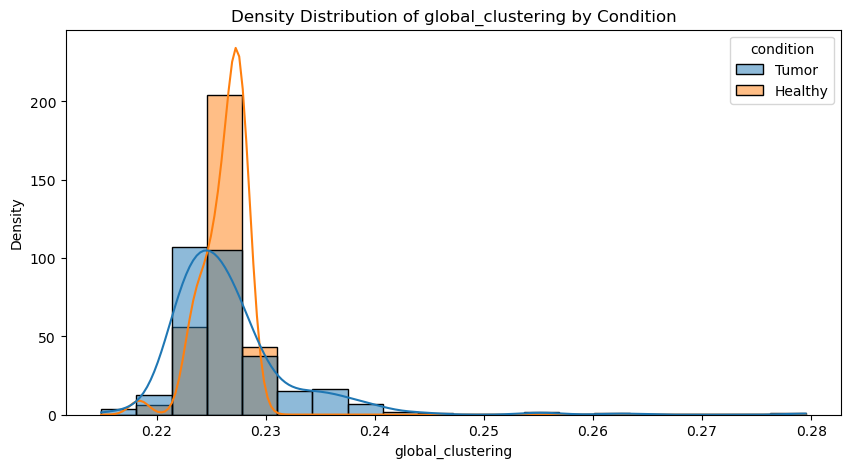

In [32]:
metric = 'global_clustering'

plt.figure(figsize=(10,5))
sns.histplot(
    data=graph_df, x=metric, hue='condition', 
    bins=20, kde=True, stat='density', common_norm=False, alpha=0.5
)
plt.title(f"Density Distribution of {metric} by Condition")
plt.xlabel(metric)
plt.ylabel("Density")
plt.show()

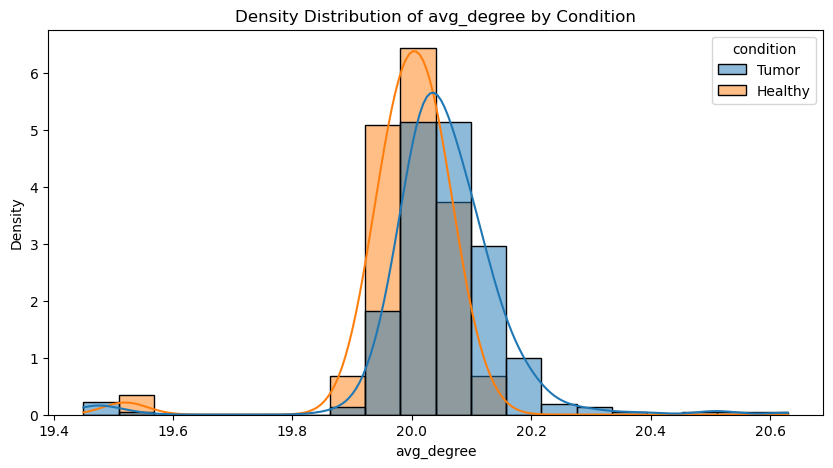

In [34]:
metric = 'avg_degree'

plt.figure(figsize=(10,5))
sns.histplot(
    data=graph_df, x=metric, hue='condition', 
    bins=20, kde=True, stat='density', common_norm=False, alpha=0.5
)
plt.title(f"Density Distribution of {metric} by Condition")
plt.xlabel(metric)
plt.ylabel("Density")
plt.show()

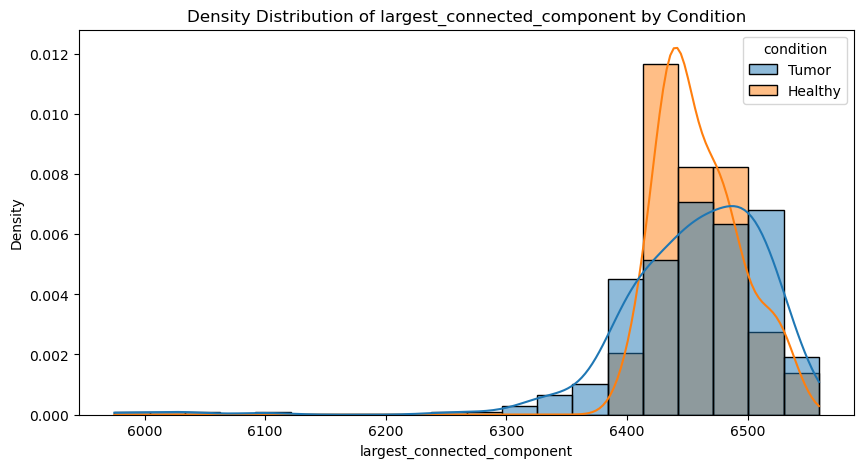

In [38]:
metric = 'largest_connected_component'

plt.figure(figsize=(10,5))
sns.histplot(
    data=graph_df, x=metric, hue='condition', 
    bins=20, kde=True, stat='density', common_norm=False, alpha=0.5
)
plt.title(f"Density Distribution of {metric} by Condition")
plt.xlabel(metric)
plt.ylabel("Density")
plt.show()

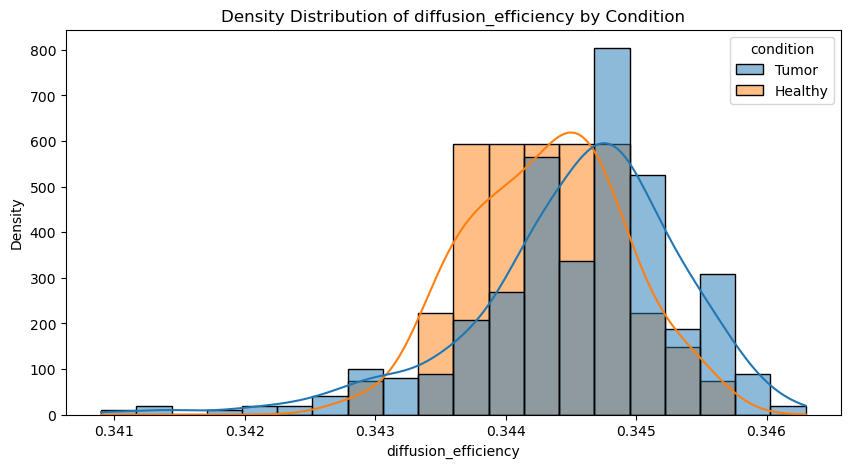

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

metric = 'diffusion_efficiency'

plt.figure(figsize=(10,5))
sns.histplot(
    data=graph_df, x=metric, hue='condition', 
    bins=20, kde=True, stat='density', common_norm=False, alpha=0.5
)
plt.title(f"Density Distribution of {metric} by Condition")
plt.xlabel(metric)
plt.ylabel("Density")
plt.show()

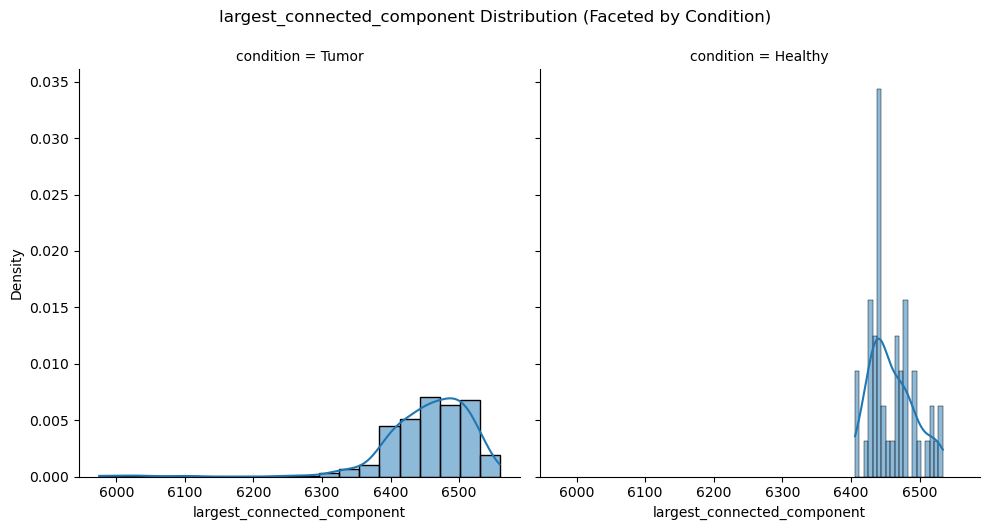

In [40]:
g = sns.FacetGrid(graph_df, col='condition', height=5, aspect=1)
g.map_dataframe(sns.histplot, x=metric, bins=20, kde=True, stat='density')
g.set_axis_labels(metric, "Density")
g.fig.suptitle(f"{metric} Distribution (Faceted by Condition)", y=1.05)
plt.show()

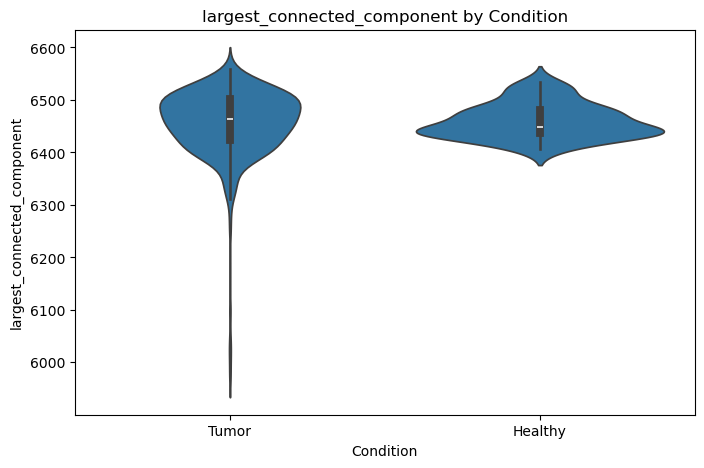

In [42]:
plt.figure(figsize=(8,5))
sns.violinplot(data=graph_df, x='condition', y=metric, inner='box')
plt.title(f"{metric} by Condition")
plt.ylabel(metric)
plt.xlabel("Condition")
plt.show()

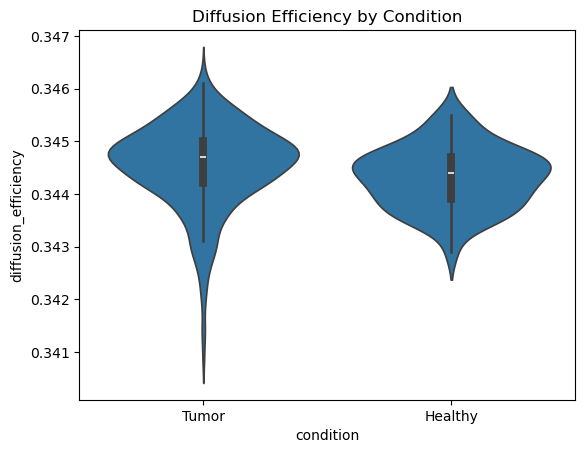

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=graph_df, x='condition', y='diffusion_efficiency')
plt.title("Diffusion Efficiency by Condition")
plt.show()

In [44]:
# Stats 
from scipy.stats import mannwhitneyu

# Example for avg_local_clustering
metric = 'avg_local_clustering'

healthy_values = graph_df[graph_df['condition'] == 'Healthy'][metric]
tumor_values = graph_df[graph_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy_values, tumor_values, alternative='two-sided')

print(f"Mann-Whitney U test for {metric}:\nStatistic = {stat:.4f}, p-value = {p:.4f}")

Mann-Whitney U test for avg_local_clustering:
Statistic = 4304.0000, p-value = 0.0000


In [46]:
metric = 'global_clustering'

healthy_values = graph_df[graph_df['condition'] == 'Healthy'][metric]
tumor_values = graph_df[graph_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy_values, tumor_values, alternative='two-sided')

print(f"Mann-Whitney U test for {metric}:\nStatistic = {stat:.4f}, p-value = {p:.4f}")

Mann-Whitney U test for global_clustering:
Statistic = 10704.5000, p-value = 0.0893


In [48]:
metric = 'avg_degree'

healthy_values = graph_df[graph_df['condition'] == 'Healthy'][metric]
tumor_values = graph_df[graph_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy_values, tumor_values, alternative='two-sided')

print(f"Mann-Whitney U test for {metric}:\nStatistic = {stat:.4f}, p-value = {p:.4f}")

Mann-Whitney U test for avg_degree:
Statistic = 5043.0000, p-value = 0.0000


In [62]:
metric = 'largest_connected_component'
 
healthy_values = graph_df[graph_df['condition'] == 'Healthy'][metric]
tumor_values = graph_df[graph_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy_values, tumor_values, alternative='two-sided')

print(f"Mann-Whitney U test for {metric}:\nStatistic = {stat:.4f}, p-value = {p:.4f}")

Mann-Whitney U test for largest_connected_component:
Statistic = 8927.5000, p-value = 0.6248


In [81]:
metric = 'diffusion_efficiency'
 
healthy_values = graph_df[graph_df['condition'] == 'Healthy'][metric]
tumor_values = graph_df[graph_df['condition'] == 'Tumor'][metric]

stat, p = mannwhitneyu(healthy_values, tumor_values, alternative='two-sided')

print(f"Mann-Whitney U test for {metric}:\nStatistic = {stat:.4f}, p-value = {p:.4f}")

Mann-Whitney U test for diffusion_efficiency:
Statistic = 6930.0000, p-value = 0.0031


In [83]:
# Saving the file : 
#graph_df.to_csv('graph_data.csv', index=False)